In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import plotly.express as px
import statistics
from datetime import datetime, date, timedelta

In [2]:
df = pd.read_csv(
    "extract-3-very-clean.csv",
    dtype={
        "District code":             "str",
        "Property ID":               "str",
        "Sale counter":              "str",
        "Download date / time":      "str",
        "Property name":             "str",
        "Property unit number":      "str",
        "Property house number":     "str",
        "Property street name":      "str",
        "Property locality":         "str",
        "Property post code":        "float32",
        "Area":                      "float32",
        "Area type":                 "str",
        "Contract date":             "str",
        "Settlement date":           "str",
        "Purchase price":            "float64",
        "Zoning":                    "str",
        "Nature of property":        "str",
        "Primary purpose":           "str",
        "Strata lot number":         "str",
        "Dealing number":            "str",
        "Property legal description": "str",
    },
)

In [3]:
#See how many records are included
df.size

141321348

In [4]:
df["Contract date"]  = pd.to_datetime(df["Contract date"],  errors="coerce")
df["Settlement date"] = pd.to_datetime(df["Settlement date"], errors="coerce")
df.dtypes

District code                            str
Property ID                              str
Sale counter                             str
Download date / time                     str
Property name                            str
Property unit number                     str
Property house number                    str
Property street name                     str
Property locality                        str
Property post code                   float32
Area                                 float32
Area type                                str
Contract date                 datetime64[us]
Settlement date               datetime64[us]
Purchase price                       float64
Zoning                                   str
Nature of property                       str
Primary purpose                          str
Strata lot number                        str
Dealing number                           str
Property legal description               str
dtype: object

In [51]:
#Filter the dataset to your own search area
#(could obvs filter by whatever, but this is my search area)

property_locations = ['Mascot']
property_streetname = None #e.g.: ['Railway Ave']
include_zoning = ['R2']
# exclude_zoning = ['IN1', 'IN2', 'I', 'B', 'B1', 'B2', 'B7']
exclude_primary_purpose = ['Service stations', 'Service stati', 'Service statio', 'Shop', 'Hall', 'Commercial']
include_only_primary_purpose = None #e.g.: ['Vacant land']
postcode_min = 2000
postcode_max = 2999
price_min = None
price_max = 5000000
area_min = 100
area_max = None
start_date = '1990-01-01'
end_date = '2100-01-01'

#Go ahead and implement all of the above filters
df_myarea = df
if property_locations: df_myarea = df_myarea[ df_myarea['Property locality'].isin(property_locations) ] #In location specified
if property_streetname: df_myarea = df_myarea[ df_myarea['Property street name'].isin(property_streetname) ] #In street name exactly specified
if area_min: df_myarea = df_myarea[ df_myarea['Area'] >= area_min ] #More than minimum area size
if area_max: df_myarea = df_myarea[ df_myarea['Area'] <= area_max ] #Less than maximum area size
if postcode_min: df_myarea = df_myarea[ df_myarea['Property post code'] >= postcode_min ] #In postcode range
if postcode_max: df_myarea = df_myarea[ df_myarea['Property post code'] <= postcode_max ] #In postcode range
if price_min: df_myarea = df_myarea[ df_myarea['Purchase price'] >= price_min ] #More than minimum price
if price_max: df_myarea = df_myarea[ df_myarea['Purchase price'] <= price_max ] #Less than maximum price
if include_zoning: df_myarea = df_myarea[ df_myarea['Zoning'].isin(include_zoning) ] #Include explicit zone types
# if exclude_zoning: df_myarea = df_myarea[ ~df_myarea['Zoning'].isin(exclude_zoning) ] #Exclude weird zoning types
if start_date: df_myarea = df_myarea[ df_myarea['Contract date'] >= start_date] #Make sure all values are in the correct date range
if end_date: df_myarea = df_myarea[ df_myarea['Contract date'] <= end_date] #Make sure all values are in the correct date range
if exclude_primary_purpose: df_myarea = df_myarea[ ~df_myarea['Primary purpose'].isin(exclude_primary_purpose) ] #Exclude weird zoning types
if include_only_primary_purpose: df_myarea = df_myarea[ df_myarea['Primary purpose'].isin(include_only_primary_purpose) ] #Include only these zoning types

print(str(len(df_myarea.index)) + ' records kept')

907 records kept


In [52]:
#Show zoning and purpose types in the dataset
#Types: https://www.valuergeneral.nsw.gov.au/__data/assets/pdf_file/0019/216406/Property_Sales_Data_File_Zone_Codes_and_Descriptions_V2.pdf

display(df_myarea['Primary purpose'].unique())
display(df_myarea['Zoning'].unique())

<StringArray>
['Residence', 'House', 'Vacant Land', nan, 'Mechanics']
Length: 5, dtype: str

<StringArray>
['R2']
Length: 1, dtype: str

In [53]:
#Fix NaNs
df_myarea['Zoning'].fillna(value='None', inplace=True)
df_myarea['Area'].fillna(value=0, inplace=True)
df_myarea['Purchase price'].fillna(value=0, inplace=True)

/var/folders/m2/2zh5b68d5b92gmyhffzbjxgr0000gn/T/ipykernel_13853/3730339706.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_myarea['Zoning'].fillna(value='None', inplace=True)
/var/folders/m2/2zh5b68d5b92gmyhffzbjxgr0000gn/T/ipykernel_13853/3730339706.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame 

4090291    1072000.0
4094273     800000.0
4094280     766000.0
4101027     840000.0
4107445     930000.0
             ...    
6725327    2240000.0
6725333    1350000.0
6725334    1600000.0
6725359    1680000.0
6729127    1257000.0
Name: Purchase price, Length: 907, dtype: float64

In [54]:
#Remove purchase price outliers

before=len(df_myarea.index)

#Display the outliers
display(df_myarea[(np.abs(stats.zscore(df_myarea['Purchase price'])) >= 3)])

#Remove them from the data
#df_myarea = df_myarea[(np.abs(stats.zscore(df_myarea['Purchase price'])) < 3)]

after=len(df_myarea.index)
print('Removed ' + str(before-after) + ' outliers (more than 3 standard deviations from the mean).')

,District code,Property ID,Sale counter,Download date / time,Property name,Property unit number,Property house number,Property street name,Property locality,Property post code,...,Area type,Contract date,Settlement date,Purchase price,Zoning,Nature of property,Primary purpose,Strata lot number,Dealing number,Property legal description
5842529,276,3140386,20,20211004 01:51,Linden Gardens,5,15,Linden St,Mascot,2020.0,...,M,2021-05-07,2021-09-30,3165000.0,R2,R,Residence,NaN,AR475643,5/285886
6202617,276,1889887,14,20230821 01:15,NaN,NaN,15,Hicks Ave,Mascot,2020.0,...,M,2023-06-07,2023-08-15,3400000.0,R2,R,Residence,NaN,AT353625,35/3/937
6600826,276,1892988,61,20250908 01:08,NaN,NaN,4,Ney St,Mascot,2020.0,...,M,2025-08-27,2025-09-04,4800000.0,R2,R,Residence,NaN,AV392931,20/3/937


Removed 0 outliers (more than 3 standard deviations from the mean).


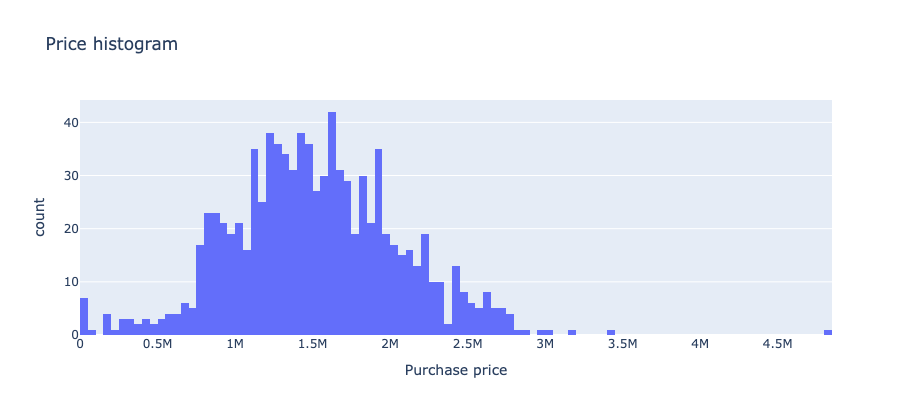

In [55]:
# Price distribution by 5-year period
# A flat histogram conflates decades of price growth — this shows how the distribution has shifted
df_hist = df_myarea[df_myarea['Purchase price'] > 0].copy()
df_hist['Period'] = (
    (df_hist['Contract date'].dt.year // 5 * 5).astype(str) + '–' +
    (df_hist['Contract date'].dt.year // 5 * 5 + 4).astype(str)
)

fig = px.box(
    df_hist.sort_values('Contract date'),
    x='Period',
    y='Purchase price',
    title='Purchase price distribution by 5-year period',
    points=False,
    width=1000,
    height=500,
)
fig.show()

# Current market histogram — last 5 years only (apples-to-apples)
recent_years = 5
cutoff = df_myarea['Contract date'].max() - pd.DateOffset(years=recent_years)
df_recent = df_myarea[
    (df_myarea['Contract date'] >= cutoff) &
    (df_myarea['Purchase price'] > 0)
]

if not df_recent.empty:
    median_price = df_recent['Purchase price'].median()
    fig = px.histogram(
        df_recent,
        x='Purchase price',
        nbins=int(df_recent['Purchase price'].max() / 50000),
        title=f'Price histogram — last {recent_years} years only  (${median_price:,.0f} median)',
        width=1000,
        height=400,
    )
    fig.show()

In [56]:
#Show the top 5 most expensive properties in the area

df_myarea.sort_values('Purchase price', ascending=False).head(5)

,District code,Property ID,Sale counter,Download date / time,Property name,Property unit number,Property house number,Property street name,Property locality,Property post code,...,Area type,Contract date,Settlement date,Purchase price,Zoning,Nature of property,Primary purpose,Strata lot number,Dealing number,Property legal description
6600826,276,1892988,61,20250908 01:08,NaN,NaN,4,Ney St,Mascot,2020.0,...,M,2025-08-27,2025-09-04,4800000.0,R2,R,Residence,NaN,AV392931,20/3/937
6202617,276,1889887,14,20230821 01:15,NaN,NaN,15,Hicks Ave,Mascot,2020.0,...,M,2023-06-07,2023-08-15,3400000.0,R2,R,Residence,NaN,AT353625,35/3/937
5842529,276,3140386,20,20211004 01:51,Linden Gardens,5,15,Linden St,Mascot,2020.0,...,M,2021-05-07,2021-09-30,3165000.0,R2,R,Residence,NaN,AR475643,5/285886
5838179,276,1889428,28,20210927 02:53,NaN,NaN,5,Hardie St,Mascot,2020.0,...,M,2021-05-26,2021-09-22,3000000.0,R2,R,Residence,NaN,AR450629,"9, 10/3/1873"
6714660,276,1891685,49,20260406 01:04,NaN,NaN,14,Lyon St,Mascot,2020.0,...,M,2025-12-05,2026-03-27,2980000.0,R2,R,Residence,NaN,AV982741,1/999174


In [57]:
#Show all properties with a purchase price of 0 (these are likely missing values)

df_myarea[df_myarea['Purchase price'] == 0]

,District code,Property ID,Sale counter,Download date / time,Property name,Property unit number,Property house number,Property street name,Property locality,Property post code,...,Area type,Contract date,Settlement date,Purchase price,Zoning,Nature of property,Primary purpose,Strata lot number,Dealing number,Property legal description


In [58]:
#Display all the records.
display(df_myarea)

,District code,Property ID,Sale counter,Download date / time,Property name,Property unit number,Property house number,Property street name,Property locality,Property post code,...,Area type,Contract date,Settlement date,Purchase price,Zoning,Nature of property,Primary purpose,Strata lot number,Dealing number,Property legal description
4090291,203,1888194,7,20130805 01:15,NaN,NaN,55,Forster St,Mascot,2020.0,...,M,2013-05-18,2013-07-16,1072000.0,R2,R,Residence,NaN,AH896223,5/23816
4094273,203,3615004,2,20130812 01:25,NaN,NaN,109,Sutherland St,Mascot,2020.0,...,M,2013-06-12,2013-07-31,800000.0,R2,R,Residence,NaN,AH926162,21/1165884
4094280,203,1894639,9,20130812 01:25,NaN,NaN,103 A,Sutherland St,Mascot,2020.0,...,M,2013-04-02,2013-06-21,766000.0,R2,R,Residence,NaN,AH937747,Y/163420
4101027,203,1887105,4,20130826 01:16,NaN,NaN,16,Dransfield Ave,Mascot,2020.0,...,M,2013-06-27,2013-08-08,840000.0,R2,R,Residence,NaN,AH955226,8/221071
4107445,203,1892578,9,20131209 01:15,NaN,NaN,39,Mcburney Ave,Mascot,2020.0,...,M,2013-09-28,2013-11-15,930000.0,R2,R,Residence,NaN,AI191360,70/5033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6725327,276,1890407,35,20260427 01:05,NaN,NaN,1,Hughes Ave,Mascot,2020.0,...,M,2026-02-17,2026-04-17,2240000.0,R2,R,Residence,NaN,AW41225,23/20146
6725333,276,1893998,41,20260427 01:05,NaN,NaN,91,Robey St,Mascot,2020.0,...,M,2026-03-08,2026-04-20,1350000.0,R2,R,Residence,NaN,AW46165,156/135994
6725334,276,1891854,42,20260427 01:05,NaN,NaN,25,Malcolm St,Mascot,2020.0,...,M,2026-04-02,2026-04-21,1600000.0,R2,R,Residence,NaN,AW52348,B/385545
6725359,276,1889466,70,20260427 01:05,NaN,NaN,83,Hardie St,Mascot,2020.0,...,M,2026-02-19,2026-04-17,1680000.0,R2,R,Residence,NaN,AW44791,21/1099877


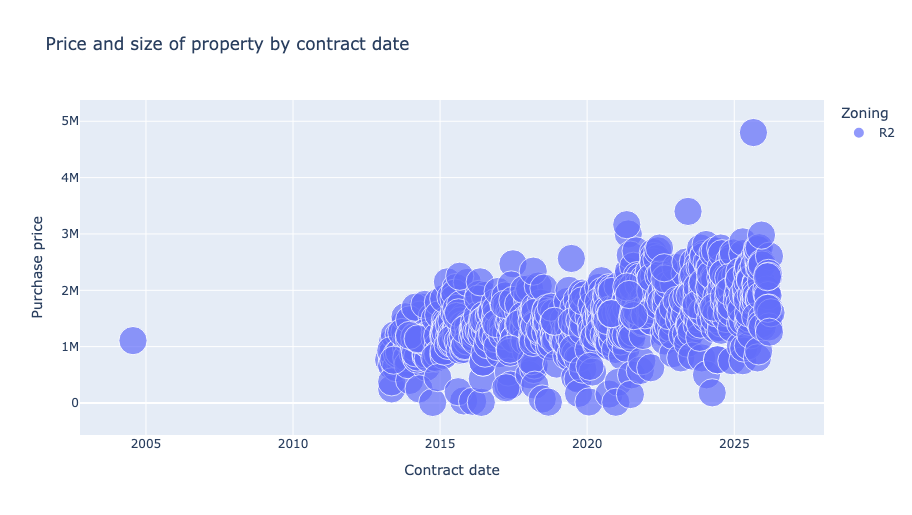

In [59]:
#Price by size and contract date

#Scale property size so the dots don't get too small
median = statistics.median(df_myarea['Area'])
df_myarea['Area - scaled'] = [(x - median) / 1000 + median for x in df_myarea['Area']]

fig = px.scatter(
    df_myarea,
    x='Contract date',
    y='Purchase price',    
    size='Area - scaled',
    color='Zoning',
    title='Price and size of property by contract date',
    width=1000,
    height=500,
    labels={'x':'Contract date'},
    hover_name=df_myarea['Property house number'] + ' ' + df_myarea['Property street name'] + ', ' + df_myarea['Property locality'],
    hover_data={
        'Area - scaled':False,
        'Zoning':True,
        'Area':True
    }
)

fig.show()

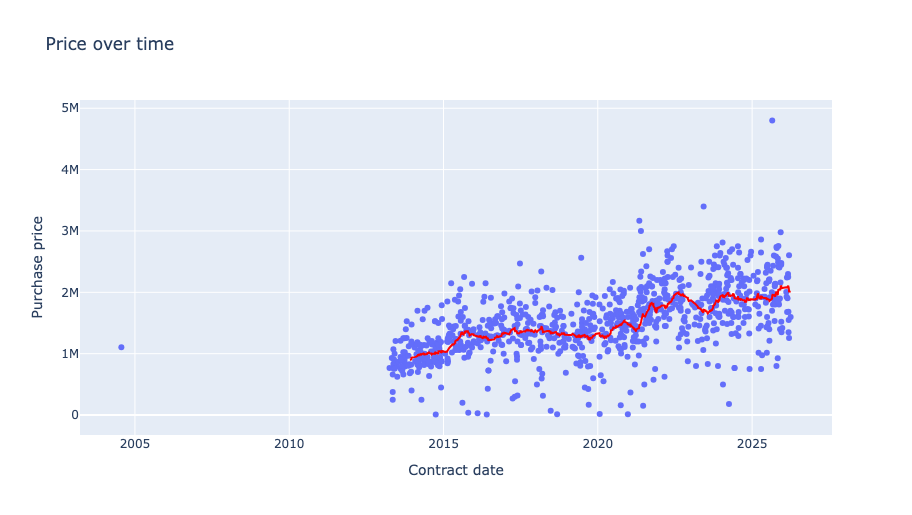

In [60]:
#Price by contract date

fig = px.scatter(
    df_myarea,
    x='Contract date',
    y='Purchase price',    
    title='Price over time',
    trendline='rolling',
    trendline_options=dict(window=45),    
    trendline_color_override="red",
    width=1000,
    height=500,
    labels={'x':'Contract date'},
    hover_name=df_myarea['Property house number'] + ' ' + df_myarea['Property street name'] + ', ' + df_myarea['Property locality'],
    hover_data={
        'Area - scaled':False,
        'Zoning':True,
        'Area':True
    }
)

fig.show()

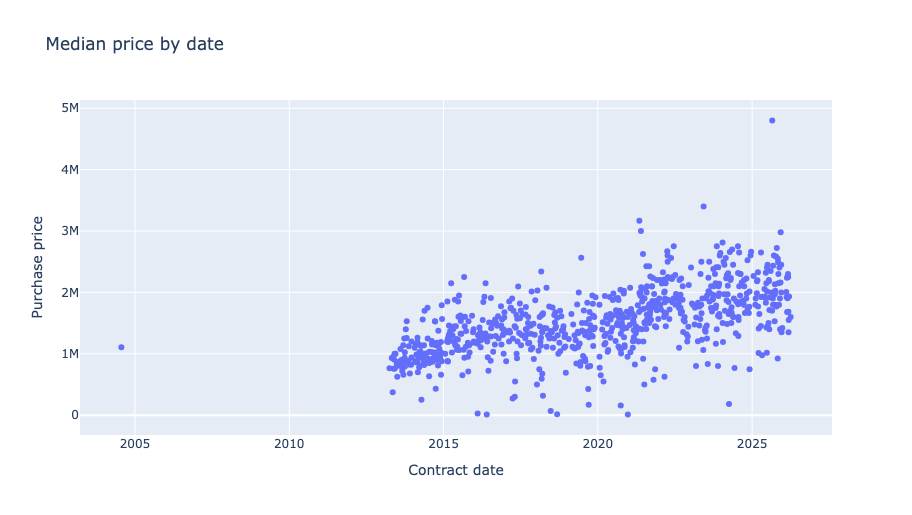

In [61]:
#Median price by contract date

df_myarea_agg=df_myarea[['Contract date','Purchase price']]
df_myarea_agg=df_myarea_agg.groupby(['Contract date']).median()
#This is the same as above:
##df_myarea_agg=df_myarea_agg.groupby(([pd.Grouper(key='Contract date', freq='D')])).median()

fig = px.scatter(
    df_myarea_agg,
    x=df_myarea_agg.index.values,
    y='Purchase price',    
    title='Median price by date',
    width=1000,
    height=500,
    labels={'x':'Contract date'},
)

fig.show()

In [62]:
#Get last downloaded file date and set variable 90 days before that
d = datetime.now()
offset = -datetime.now().weekday() - 7 - 90
this_date = (datetime.now() + timedelta(offset))
print(this_date)

2026-02-10 17:12:56.301552


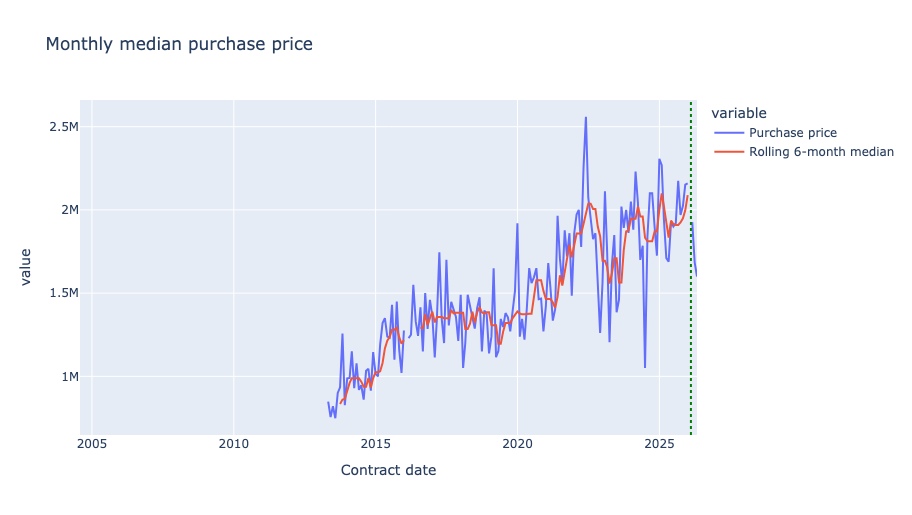

In [63]:
#Monthly median price

df_myarea_aggM = df_myarea[['Contract date', 'Purchase price']]
df_myarea_aggM = df_myarea_aggM.groupby([pd.Grouper(key='Contract date', freq='ME')]).agg('median')

df_myarea_aggM['Rolling 6-month median'] = df_myarea_aggM.rolling(6).median()

#Could also do this if we wanted to show multiple types - e.g. mean, sum, etc
#g1 = df_myarea_m.groupby(pd.Grouper(key='Contract date', freq="M")).median()
#g2 = df_myarea_m.groupby(pd.Grouper(key='Contract date', freq="M")).mean()
#g = g1.merge(g2, left_on='Contract date', right_on='Contract date', suffixes=(' median', ' mean'))

fig = px.line(
    df_myarea_aggM,
    title='Monthly median purchase price',
    width=1000,
    height=500
)

fig.add_vline(x=this_date, line_width=2, line_dash="dot", line_color="green")
fig.show()

In [64]:
#Sales volume by month

latest_date = df_myarea['Contract date'].max() - timedelta(days=90)

df_myarea_aggMc = df_myarea[['Contract date', 'Purchase price']]
df_myarea_aggMc = df_myarea_aggMc.groupby([pd.Grouper(key='Contract date', freq='M')]).agg('count')
df_myarea_aggMc.rename(columns={'Purchase price':'Number of sales'}, inplace=True)
df_myarea_aggMc['Rolling 6-month median'] = df_myarea_aggMc.rolling(6).median()


fig = px.line(
    df_myarea_aggMc,
    title='Sales volume by month',
    width=1000,
    height=500
)

fig.add_vline(x=this_date, line_width=2, line_dash="dot", line_color="green")
fig.show()

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

---
## Street-Level Query with Spatial Map

Query all sales on a specific street within a date range and plot each sale on an interactive map.

Addresses are geocoded via OpenStreetMap (Nominatim) and cached locally in `geocode_cache.csv` so subsequent runs are instant.

> **Requirement:** `geopy` — already in `requirements.txt`.

In [ ]:
# --- Parameters: edit these to query any street and date range ---

query_street     = 'King St'       # title case; partial match (catches 'King St', 'King Street', etc.)
query_locality   = 'Mascot'        # suburb name, title case
query_postcode   = 2020            # set to None to skip
query_start_date = '2020-01-01'
query_end_date   = '2020-12-31'

In [ ]:
# Filter the main dataframe to the street query
df_street = df[
    df['Property street name'].str.contains(query_street, case=False, na=False) &
    (df['Property locality'].str.upper() == query_locality.upper()) &
    (df['Contract date'] >= query_start_date) &
    (df['Contract date'] <= query_end_date)
].copy()

if query_postcode is not None:
    df_street = df_street[df_street['Property post code'] == float(query_postcode)]

df_street = df_street.sort_values('Contract date').reset_index(drop=True)

print(f"{len(df_street)} sales found on {query_street}, {query_locality} "
      f"between {query_start_date} and {query_end_date}")
df_street[['Property house number','Property street name','Property locality',
           'Contract date','Purchase price','Area','Zoning']]

In [ ]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

GEOCODE_CACHE = 'geocode_cache.csv'

_cache = (
    pd.read_csv(GEOCODE_CACHE, index_col='address')
    if os.path.exists(GEOCODE_CACHE)
    else pd.DataFrame(columns=['address', 'lat', 'lng']).set_index('address')
)

_geolocator = Nominatim(user_agent='nsw-property-sales-analysis')
_geocode    = RateLimiter(_geolocator.geocode, min_delay_seconds=1, error_wait_seconds=5)

def _geocode_row(row):
    """Return (lat, lng) for a property row, reading from cache first."""
    postcode = int(row['Property post code']) if pd.notna(row['Property post code']) else ''
    house    = str(row['Property house number']).strip() if pd.notna(row['Property house number']) else ''
    address  = f"{house} {row['Property street name']}, {row['Property locality']} NSW {postcode}, Australia".strip()
    if address in _cache.index:
        return _cache.loc[address, 'lat'], _cache.loc[address, 'lng']
    try:
        loc = _geocode(address)
        lat, lng = (loc.latitude, loc.longitude) if loc else (None, None)
    except Exception as e:
        print(f'Geocoding failed for {address}: {e}')
        lat, lng = None, None
    _cache.loc[address] = [lat, lng]
    _cache.to_csv(GEOCODE_CACHE)
    return lat, lng

print(f'Geocoding {len(df_street)} addresses...')
print('Tip: delete geocode_cache.csv to force a full re-geocode if results look wrong.')
df_street[['lat', 'lng']] = df_street.apply(_geocode_row, axis=1, result_type='expand')
df_geo = df_street.dropna(subset=['lat', 'lng']).copy()
print(f'Geocoded {len(df_geo)} of {len(df_street)} records '
      f'({len(df_street) - len(df_geo)} could not be located)')

In [ ]:
df_geo = df_geo.copy()
df_geo['Address'] = (
    df_geo['Property house number'].fillna('').astype(str) + ' ' +
    df_geo['Property street name'].fillna('') + ', ' +
    df_geo['Property locality'].fillna('')
).str.strip()
df_geo['Sale date']       = df_geo['Contract date'].dt.strftime('%d %b %Y')
df_geo['Formatted price'] = df_geo['Purchase price'].apply(
    lambda x: f'${x:,.0f}' if pd.notna(x) else 'N/A'
)
df_geo['Area (m²)'] = df_geo['Area'].apply(
    lambda x: f'{x:,.0f} m²' if pd.notna(x) else 'N/A'
)

# Nominatim often resolves to street centroids rather than exact house positions.
# Jitter spreads co-located points ~15 m apart so they don't stack on each other.
_rng    = np.random.default_rng(seed=42)
_jitter = 0.00015  # degrees ≈ 15 metres at Sydney latitude
df_geo['lat'] = df_geo['lat'] + _rng.uniform(-_jitter, _jitter, len(df_geo))
df_geo['lng'] = df_geo['lng'] + _rng.uniform(-_jitter, _jitter, len(df_geo))

fig = px.scatter_mapbox(
    df_geo,
    lat='lat',
    lon='lng',
    color='Purchase price',
    size='Purchase price',
    size_max=30,
    hover_name='Address',
    hover_data={
        'Formatted price': True,
        'Sale date':        True,
        'Area (m²)':        True,
        'Zoning':           True,
        'Purchase price':   False,
        'lat':              False,
        'lng':              False,
    },
    labels={'Formatted price': 'Purchase price', 'Sale date': 'Contract date'},
    color_continuous_scale=px.colors.sequential.Plasma,
    zoom=15,
    mapbox_style='open-street-map',
    title=f'Sales on {query_street}, {query_locality}  |  {query_start_date} → {query_end_date}  (positions approximate)',
    width=1000,
    height=650,
)
fig.update_layout(margin={'r': 0, 't': 45, 'l': 0, 'b': 0})
fig.show()